# Floquet engineering in graphene: two tr-ARPES experiments, one model

Graphene was the *first* proposed platform for Floquet engineering — Oka & Aoki,
*PRB* **79**, 081406(R) (2009) — and the last to yield a clean spectroscopic
measurement. Two experiments settled it, a year apart, on nominally the same
material:

**Choi, Mogi, De Giovannini, Azoury, Lv, Su, Hübener, Rubio & Gedik**,
*Nature Physics* **21**, 1100 (2025) (arXiv:2404.14392) — monolayer epitaxial
graphene on SiC, pumped at $\hbar\omega = 246$ meV. They see replicas of the
Dirac cone at $\pm\hbar\omega$, and explicitly **no avoided-crossing gap**,
because the substrate-induced gap at the Dirac point ($\approx 0.27$ eV) exceeds
the photon energy, so successive replicas never cross.

**Wang, Cai, Tang, Lu, Chen, Sheng, Feng, Zhong, Zhang, Yu & Zhou**,
*Nature Materials* (2026) (arXiv:2603.28725) — the same material, pumped at
$\hbar\omega = 490$ meV, above that gap. Now the replicas *do* cross, and a
hybridization gap $\Delta = 241 \pm 18$ meV opens at the crossings. It is
strongly anisotropic: maximal for $\mathbf k \perp \mathbf E$, vanishing for
$\mathbf k \parallel \mathbf E$, leaving two nodes on the resonance ring.

Together they are a much sharper test than either alone, because the *same*
model has to produce "no gap" at one photon energy and 241 meV at the other,
with the switch controlled by a parameter neither experiment fits.

## The numbers, as published

Their own comparison table (Wang *et al.*, Extended Data Table 1) — $E_i$ is the
**in-plane field inside the sample**, after Fresnel transmission, which is what
the Peierls substitution sees:

| | Aeschlimann | Merboldt | Choi *et al.* | Wang *et al.* | Wang *et al.* |
|---|---|---|---|---|---|
| $\hbar\omega$ (meV) | 280 | 650 | 246 | **490** | 600 |
| fluence (mJ/cm²) | 2 | 1.23 | 0.0254 | 4.1 | 6.0 |
| $E$ in vacuum (V/m) | $2.4{\times}10^8$ | $3{\times}10^8$ | $0.27{\times}10^8$ | $4.8{\times}10^8$ | $6.3{\times}10^8$ |
| $E_i$ in-plane, in sample | — | — | $0.082{\times}10^8$ | $1.8{\times}10^8$ | $2.4{\times}10^8$ |
| $\beta = ev_FE_i/\hbar\omega^2$ | — | 0.108 | 0.085 | 0.49 | 0.44 |
| $\Delta$ (meV) | — | 70 (calc.) | 21 (calc.) | **241 ± 18 (meas.)** | 263 (calc.) |
| resolution (meV) | 150 | 155 | 53 | 71 | 71 |

Their $\Delta = \beta\hbar\omega$ is exactly $\hbar v_F A_0$ with $A_0 = E_i/\omega$
— the same law the Bi$_2$Se$_3$ dynamical gap obeys in notebook 25. So the first
thing to check is that this code's amplitude convention *is* theirs, before any
band structure is involved.

In [1]:
import sys, pathlib, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import torch

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
warnings.simplefilter('ignore')

import waw
waw.set_num_threads(16)
from ase import Atoms
from waw.core.hamiltonian import HamiltonianR
from waw.analysis.elph import band_eigensystem
from waw.analysis.floquet import (drive_amplitude_from_field, floquet_convergence,
                                  floquet_quasi_energies, floquet_spectral_function)
from waw.interfaces.ase.structure import real_lattice, recip_lattice
from waw.units import BOHR_TO_ANG, EV_TO_HARTREE, HARTREE_TO_EV

RUNS = REPO / 'workflows' / 'notebooks' / 'runs'
ANG_TO_BOHR = 1.0 / BOHR_TO_ANG      # a length,   Ang   -> Bohr
IA_TO_IB = BOHR_TO_ANG               # a momentum, 1/Ang -> 1/Bohr
CAT = ['#14487f', '#c1666b', '#4a7c59', '#8a6bbe']
BLUE_RAMP = ['#a8c8ec', '#4f8bd0', '#14487f']

# the published runs: (label, hbar omega in eV, in-plane field in V/m, quoted Delta)
RUNS_EXP = [('Choi 2025',   0.246, 0.082e8,  21.0, 'calc.'),
            ('Merboldt',    0.650, None,     70.0, 'calc.'),
            ('Wang 490',    0.490, 1.8e8,   241.0, 'meas. +-18'),
            ('Wang 600',    0.600, 2.4e8,   263.0, 'calc.')]
HBAR_V_EXP = 6.582119569e-16 * 1.0e6 * 1.0e10     # hbar * 1e6 m/s, in eV Ang
print(f'experimental Fermi velocity 1e6 m/s  ->  hbar v = {HBAR_V_EXP:.3f} eV Ang')
print('\ncheck the amplitude convention against their own beta = e v_F E_i / (hbar omega)^2:')
print(f"{'run':12s} {'hbar w':>7s} {'A0 (1/Bohr)':>12s} {'hbar v A0':>10s} {'published':>10s}")
for lab, w_ev, Ei, dpub, kind in RUNS_EXP:
    if Ei is None:
        continue
    a0 = drive_amplitude_from_field(Ei, w_ev)
    v_au = HBAR_V_EXP / (HARTREE_TO_EV * BOHR_TO_ANG)
    print(f'{lab:12s} {w_ev:7.3f} {a0:12.5f} {v_au*a0*HARTREE_TO_EV*1e3:9.1f} meV '
          f'{dpub:6.0f} meV ({kind})')

experimental Fermi velocity 1e6 m/s  ->  hbar v = 6.582 eV Ang

check the amplitude convention against their own beta = e v_F E_i / (hbar omega)^2:
run           hbar w  A0 (1/Bohr)  hbar v A0  published
Choi 2025      0.246      0.00176      21.9 meV     21 meV (calc.)
Wang 490       0.490      0.01944     241.8 meV    241 meV (meas. +-18)
Wang 600       0.600      0.02117     263.3 meV    263 meV (calc.)


## 1. An ab initio $\pi$/$\pi^*$ model of graphene

Two $p_z$ MLWFs from a fresh PBE run (15×15×1, 60 Ry, 20 Å vacuum, 2D Coulomb
cutoff), disentangled with a frozen window narrow enough that only $\pi$/$\pi^*$
live inside it anywhere in the zone. That is the manifold both experiments
probe, and the Peierls coupling then comes from the material's own $H(\mathbf R)$
rather than from a Dirac Hamiltonian written down by hand.

The substrate matters. Both samples are epitaxial graphene on SiC, whose buffer
layer breaks the A/B sublattice symmetry and opens $\approx 0.26$–0.27 eV at the
Dirac point. That is added here as a Semenoff mass $\pm m\sigma_z$ on the two
Wannier centres — an explicit, stated modification of the ab initio model, and
the parameter that decides whether the replicas can cross at all.

In [2]:
A_GR = 2.4599989204
cell = np.array([[A_GR * np.sqrt(3) / 2, -A_GR / 2, 0.0],
                 [0.0, A_GR, 0.0], [0.0, 0.0, 20.0]])
atoms = Atoms('C2', cell=cell, pbc=True,
              scaled_positions=[[0.0, 0.0, 0.5], [1 / 3, 2 / 3, 0.5]])
GR = RUNS / 'graphene_floquet'
res = waw.load_wannier_result(GR / 'graphene_pz.npz')
E_F = float(np.load(GR / 'graphene_fermi.npy')[0])
REC = recip_lattice(atoms)
K_FRAC = np.array([1 / 3, 1 / 3, 0.0])
print(f'{res.hr.nw} p_z MLWFs, {len(res.hr.R_vectors)} R vectors, '
      f'Omega = {res.omega_final*BOHR_TO_ANG**2:.4f} Ang^2')
print(f'Wannier centres (Ang):\n{np.round(res.centres_bohr*BOHR_TO_ANG, 4)}')

GAP_SUB = 0.26        # eV, buffer-layer sublattice gap of epitaxial graphene/SiC

def graphene_model(gap_ev=0.0):
    # the ab initio pi/pi* model, optionally with a Semenoff sublattice mass
    H = res.hr.H_R.detach().cpu().numpy().copy()
    R0 = np.where((res.hr.R_vectors == 0).all(axis=1))[0][0]
    m = 0.5 * gap_ev * EV_TO_HARTREE * res.hr.degen[R0]
    H[R0, 0, 0] += m
    H[R0, 1, 1] -= m
    return HamiltonianR(H_R=torch.tensor(H), R_vectors=res.hr.R_vectors,
                        degen=res.hr.degen, nw=res.hr.nw, centres=res.hr.centres,
                        real_lattice=res.hr.real_lattice, mp_grid=res.hr.mp_grid)

def kpath_from_K(k_invang, phi_deg=90.0):
    # k measured from K, magnitude in 1/Ang, at azimuth phi from Cartesian x
    p = np.radians(phi_deg)
    d = np.array([np.cos(p), np.sin(p), 0.0])
    return np.array([K_FRAC + np.linalg.solve(REC.T, kv * IA_TO_IB * d)
                     for kv in np.atleast_1d(k_invang)])

bare = graphene_model(0.0)
kk = np.array([0.005, 0.01, 0.02, 0.03, 0.05])
e = band_eigensystem(bare, kpath_from_K(kk))[0] * HARTREE_TO_EV - E_F
HV = float(np.polyfit(kk[:4], 0.5 * (e[:4, 1] - e[:4, 0]), 1)[0])
eK = band_eigensystem(bare, K_FRAC[None, :])[0][0] * HARTREE_TO_EV - E_F
print(f'\nbare model: gap at K = {abs(eK[1]-eK[0])*1e3:.2f} meV (must be ~0)')
print(f'hbar v (PBE, this model) = {HV:.3f} eV Ang')
print(f'hbar v (experiment, v_F = 1e6 m/s) = {HBAR_V_EXP:.3f} eV Ang'
      f'   -> this model is {HV/HBAR_V_EXP:.3f} of it')
print('PBE underestimates the Fermi velocity of graphene; the many-body')
print('renormalisation that brings it to 1e6 m/s is not in a PBE band structure.')
print('Delta is LINEAR in v, so that ratio propagates straight through.')

gapped = graphene_model(GAP_SUB)
eKg = band_eigensystem(gapped, K_FRAC[None, :])[0][0] * HARTREE_TO_EV - E_F
print(f'\nwith the substrate mass: gap at K = {abs(eKg[1]-eKg[0])*1e3:.1f} meV')

2 p_z MLWFs, 241 R vectors, Omega = 1.8510 Ang^2
Wannier centres (Ang):
[[  0.      -0.     -10.    ]
 [  0.7101   1.23    10.    ]]

bare model: gap at K = 0.01 meV (must be ~0)
hbar v (PBE, this model) = 5.643 eV Ang
hbar v (experiment, v_F = 1e6 m/s) = 6.582 eV Ang   -> this model is 0.857 of it
PBE underestimates the Fermi velocity of graphene; the many-body
renormalisation that brings it to 1e6 m/s is not in a PBE band structure.
Delta is LINEAR in v, so that ratio propagates straight through.

with the substrate mass: gap at K = 260.0 meV


## 2. Choi *et al.*: replicas, and why no gap

At $\hbar\omega = 246$ meV the substrate gap is *larger* than the photon energy,
so the condition for a Floquet crossing,

$$E_{\rm CB}(\mathbf k) - E_{\rm VB}(\mathbf k)
= 2\sqrt{m^2 + (\hbar v k)^2} = \hbar\omega,$$

has no solution: the smallest separation the bands can have is $2m = 260$ meV,
already above 246. The paper states exactly this. Everything else the drive does
— the replicas at $\pm\hbar\omega$ — still happens, and this is the regime the
spectral function should show.

Choi et al.: hbar w = 246 meV, E_i = 8.2e+06 V/m  ->  A0 = 0.00176 1/Bohr
   Peierls phase over a C-C bond (1.42 Ang): 0.0047  -- deeply perturbative
   substrate gap 2m = 260 meV  vs  hbar w = 246 meV  ->  resonance ring exists: False


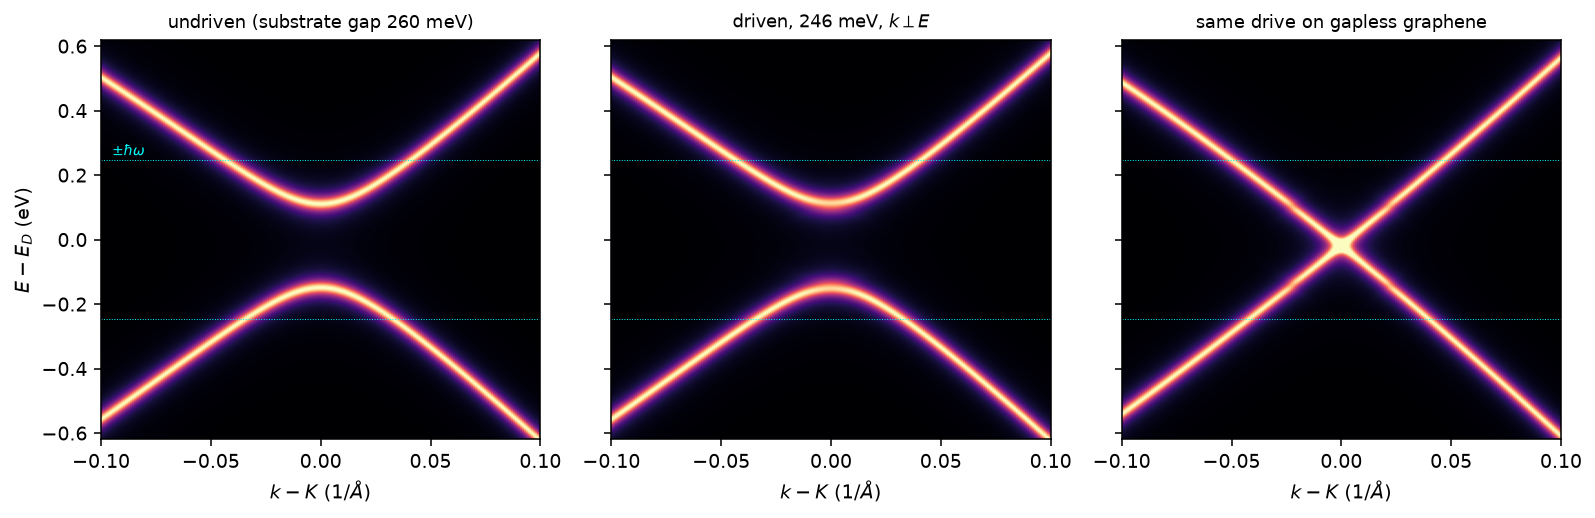

middle panel: replicas at +-246 meV, and the n=0 and n=+-1 cones pass each
other without touching -- there is no crossing to gap. Right panel: remove
the substrate mass and the same drive immediately produces avoided crossings.


In [3]:
W_A, E_A = 0.246, 0.082e8
A0_A = drive_amplitude_from_field(E_A, W_A)
w_A = W_A * EV_TO_HARTREE
print(f'Choi et al.: hbar w = {W_A*1e3:.0f} meV, E_i = {E_A:.3g} V/m'
      f'  ->  A0 = {A0_A:.5f} 1/Bohr')
print(f'   Peierls phase over a C-C bond (1.42 Ang): '
      f'{A0_A*1.42*ANG_TO_BOHR:.4f}  -- deeply perturbative')
print(f'   substrate gap 2m = {GAP_SUB*1e3:.0f} meV  vs  hbar w = {W_A*1e3:.0f} meV'
      f'  ->  resonance ring exists: {GAP_SUB < W_A}')

kA = np.linspace(-0.10, 0.10, 241)
Eax = np.linspace(-0.62, 0.62, 601)
fig, axs = plt.subplots(1, 3, figsize=(11.5, 3.8), dpi=140, sharey=True)
for ax, (mdl, amp, ttl) in zip(axs, [
        (gapped, 0.0, 'undriven (substrate gap 260 meV)'),
        (gapped, A0_A, r'driven, 246 meV, $k \perp E$'),
        (graphene_model(0.0), A0_A, 'same drive on gapless graphene')]):
    kf = np.concatenate([kpath_from_K(np.abs(kA[kA < 0]), 270.0),
                         kpath_from_K(kA[kA >= 0], 90.0)])
    A = floquet_spectral_function(mdl, kf, Eax * EV_TO_HARTREE + E_F * EV_TO_HARTREE,
                                  amplitude=amp, omega=w_A, n_photon=2,
                                  polarization='linear', broadening=0.020 * EV_TO_HARTREE)
    ax.imshow(A.T, origin='lower', aspect='auto', cmap='magma',
              extent=[kA[0], kA[-1], Eax[0], Eax[-1]], vmax=np.percentile(A, 99.5))
    for n in (-1, 1):
        ax.axhline(n * W_A, color='cyan', lw=0.5, ls=':')
    ax.set_title(ttl, fontsize=9); ax.set_xlabel(r'$k - K$ (1/$\AA$)')
axs[0].set_ylabel(r'$E - E_D$ (eV)')
axs[0].text(-0.095, 0.26, r'$\pm\hbar\omega$', color='cyan', fontsize=7)
plt.tight_layout(); plt.show()
print('middle panel: replicas at +-246 meV, and the n=0 and n=+-1 cones pass each')
print('other without touching -- there is no crossing to gap. Right panel: remove')
print('the substrate mass and the same drive immediately produces avoided crossings.')

In [4]:
# the threshold, scanned: where does a crossing first appear?
def resonance_k(model, omega_ev, phi=90.0, kmax=0.12, n=2001):
    # radius (1/Ang) where E_CB - E_VB = hbar omega, or nan if unreachable
    kk = np.linspace(1e-4, kmax, n)
    e = band_eigensystem(model, kpath_from_K(kk, phi))[0] * HARTREE_TO_EV
    sep = e[:, 1] - e[:, 0]
    if sep.min() > omega_ev or sep.max() < omega_ev:
        return np.nan
    return float(np.interp(omega_ev, sep, kk))

print(f"{'hbar w (meV)':>12s} {'resonance k (1/Ang)':>21s}   experiment")
for w_ev, tag in ((0.246, 'Choi et al.'), (0.260, 'exactly at 2m'),
                  (0.300, ''), (0.400, ''), (0.490, 'Wang et al.'), (0.600, 'Wang et al.')):
    kr = resonance_k(gapped, w_ev)
    s = 'none -- below the substrate gap' if np.isnan(kr) else f'{kr:.4f}'
    print(f'{w_ev*1e3:12.0f} {s:>21s}   {tag}')

hbar w (meV)   resonance k (1/Ang)   experiment
         246 none -- below the substrate gap   Choi et al.
         260 none -- below the substrate gap   exactly at 2m
         300                0.0134   
         400                0.0271   
         490                0.0368   Wang et al.
         600                0.0476   Wang et al.


## 3. Wang *et al.*: the 241 meV hybridization gap

Above the substrate gap the resonance ring exists and the $n=0$ and $n=\mp1$
cones cross on it. The measurement is an EDC at a resonance point: two peaks
(valence and conduction) before the pump, four after — the signature of both
crossings gapping. That is reproduced here directly, on the same quantity.

In [5]:
W_B, E_B = 0.490, 1.8e8
A0_B = drive_amplitude_from_field(E_B, W_B)
w_B = W_B * EV_TO_HARTREE
kR = resonance_k(gapped, W_B)
v_au = HV / (HARTREE_TO_EV * BOHR_TO_ANG)
print(f'Wang et al. 490 meV: A0 = {A0_B:.5f} 1/Bohr, resonance ring at '
      f'k - K = {kR:.4f} 1/Ang')
print(f'   hbar v A0 with THIS model  = {v_au*A0_B*HARTREE_TO_EV*1e3:.0f} meV')
print(f'   hbar v A0 with v = 1e6 m/s = '
      f'{HBAR_V_EXP/(HARTREE_TO_EV*BOHR_TO_ANG)*A0_B*HARTREE_TO_EV*1e3:.0f} meV'
      f'   [their calc. 240, measured 241 +- 18]')

conv = floquet_convergence(gapped, kpath_from_K([kR], 90.0), amplitude=A0_B,
                           omega=w_B, photon_range=(1, 2, 3, 4),
                           polarization='linear', e_ref=E_F * EV_TO_HARTREE)
print('\nphoton truncation:', ' '.join(
    f'n={n}: {s:.3g} meV' if s == s else f'n={n}: --'
    for n, s in zip(conv['n_photon'], conv['max_shift_meV'])))

Wang et al. 490 meV: A0 = 0.01944 1/Bohr, resonance ring at k - K = 0.0368 1/Ang
   hbar v A0 with THIS model  = 207 meV
   hbar v A0 with v = 1e6 m/s = 242 meV   [their calc. 240, measured 241 +- 18]

photon truncation: n=1: -- n=2: 4.88 meV n=3: 0.0486 meV n=4: 0.000348 meV


$k \perp E$  (   before pump EDC peaks (meV): -265  +225
$k \perp E$  (   driven      EDC peaks (meV): -361  -274  -170  +129  +234  +320
$k \parallel E   before pump EDC peaks (meV): -261  +221
$k \parallel E   driven      EDC peaks (meV): -313  -215  +175  +273


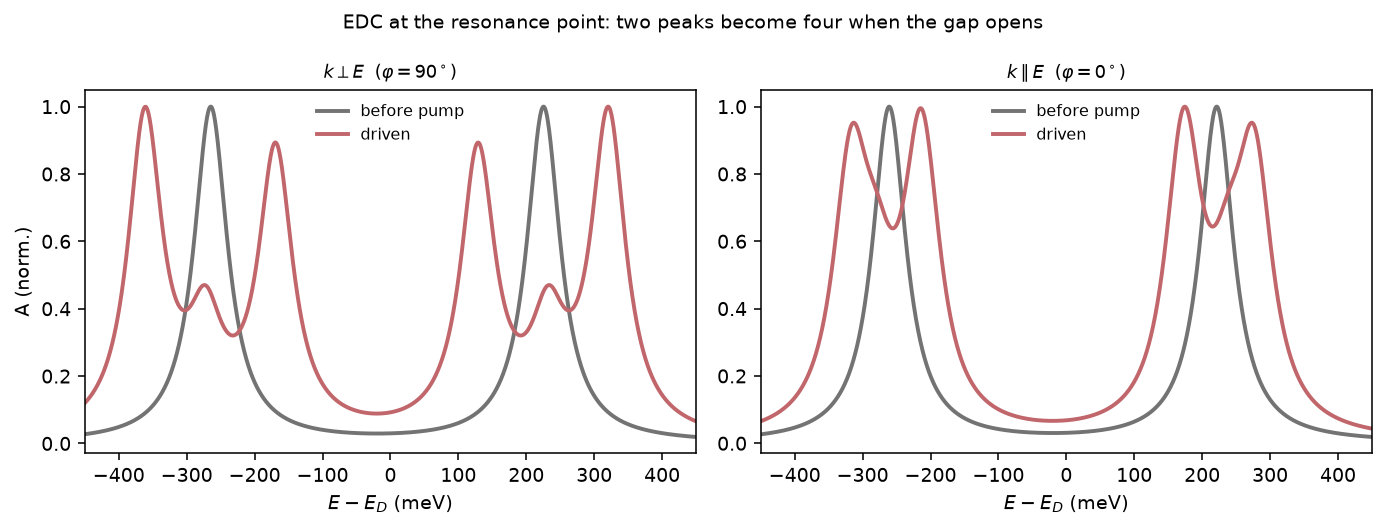

In [6]:
def edc(model, k_invang, phi, amplitude, omega, e_grid, broadening=0.030, n_photon=3):
    A = floquet_spectral_function(model, kpath_from_K([k_invang], phi),
                                  e_grid * EV_TO_HARTREE + E_F * EV_TO_HARTREE,
                                  amplitude=amplitude, omega=omega, n_photon=n_photon,
                                  polarization='linear',
                                  broadening=broadening * EV_TO_HARTREE)[0]
    return A / A.max()

def peaks(x, A, thr=0.12):
    i = np.where((A[1:-1] > A[:-2]) & (A[1:-1] > A[2:]))[0] + 1
    i = i[A[i] > thr]
    return x[i], A[i]

Eg = np.linspace(-0.45, 0.45, 2001)
fig, axs = plt.subplots(1, 2, figsize=(10, 3.8), dpi=140)
for ax, (phi, ttl) in zip(axs, [(90.0, r'$k \perp E$  ($\varphi=90^\circ$)'),
                                (0.0, r'$k \parallel E$  ($\varphi=0^\circ$)')]):
    for amp, lab, c in ((0.0, 'before pump', '0.45'), (A0_B, 'driven', CAT[1])):
        A = edc(gapped, kR, phi, amp, w_B, Eg)
        ax.plot(Eg * 1e3, A, color=c, lw=2, label=lab)
        p, h = peaks(Eg * 1e3, A)
        print(f'{ttl[:14]:16s} {lab:11s} EDC peaks (meV): '
              + '  '.join(f'{e:+.0f}' for e in p))
    ax.set_xlim(-450, 450); ax.set_xlabel(r'$E - E_D$ (meV)')
    ax.set_title(ttl, fontsize=9); ax.legend(frameon=False, fontsize=8)
axs[0].set_ylabel('A (norm.)')
plt.suptitle('EDC at the resonance point: two peaks become four when the gap opens',
             fontsize=10)
plt.tight_layout(); plt.show()

### Reading the gap off the quasi-energies

The EDC is what the experiment measures, but the quasi-energies give $\Delta$
without a lineshape in the way. At the resonance point the crossing pair is the
$n=0$ conduction state and the $n=+1$ replica of the valence state; the gap is
their minimum separation as $k$ is swept through the ring.

In [7]:
def dirac_energy(model):
    # the Dirac point of this model, eV relative to E_F -- the reference the
    # crossing sits half a photon above. Using E_F instead is a 19 meV error
    # here, which on a protected node reads as a spurious 41 meV "gap".
    e = band_eigensystem(model, K_FRAC[None, :])[0][0] * HARTREE_TO_EV - E_F
    return float(e.mean())

def floquet_gap(model, phi, amplitude, omega_ev, span=0.4, n=401, n_photon=3):
    # minimum splitting of the pair straddling E_D + hbar omega/2 near the ring
    kr = resonance_k(model, omega_ev, phi)
    if np.isnan(kr):
        return np.nan, np.nan
    kk = np.linspace((1 - span) * kr, (1 + span) * kr, n)
    eps, _ = floquet_quasi_energies(model, kpath_from_K(kk, phi), amplitude=amplitude,
                                    omega=omega_ev * EV_TO_HARTREE, n_photon=n_photon,
                                    polarization='linear')
    e = eps * HARTREE_TO_EV - E_F
    target = dirac_energy(model) + 0.5 * omega_ev
    best, kbest = np.nan, np.nan
    for i in range(len(kk)):
        below, above = e[i][e[i] < target], e[i][e[i] >= target]
        if len(below) and len(above):
            d = above.min() - below.max()
            if not (best == best) or d < best:
                best, kbest = d, kk[i]
    return best * 1e3, kbest

for lab, w_ev, Ei, dpub, kind in RUNS_EXP:
    if Ei is None:
        continue
    a0 = drive_amplitude_from_field(Ei, w_ev)
    g90, k90 = floquet_gap(gapped, 90.0, a0, w_ev)
    scaled = g90 * HBAR_V_EXP / HV if g90 == g90 else np.nan
    if g90 != g90:
        print(f'{lab:11s} hbar w = {w_ev*1e3:3.0f} meV: no resonance ring '
              f'(2m = {GAP_SUB*1e3:.0f} meV > hbar w) -- no gap, as observed')
    else:
        print(f'{lab:11s} hbar w = {w_ev*1e3:3.0f} meV: Delta = {g90:6.1f} meV '
              f'(PBE v)   {scaled:6.1f} meV (rescaled to v = 1e6 m/s)   '
              f'published {dpub:.0f} ({kind})')

Choi 2025   hbar w = 246 meV: no resonance ring (2m = 260 meV > hbar w) -- no gap, as observed
Wang 490    hbar w = 490 meV: Delta =  191.8 meV (PBE v)    223.7 meV (rescaled to v = 1e6 m/s)   published 241 (meas. +-18)
Wang 600    hbar w = 600 meV: Delta =  206.0 meV (PBE v)    240.3 meV (rescaled to v = 1e6 m/s)   published 263 (calc.)


## 4. The anisotropy, and a place where the model and the experiment disagree

This is the paper's central symmetry argument. Under a linear drive the
perturbation is $V(t) \propto v_F\,\boldsymbol\sigma\cdot\mathbf A(t)$, a
time-dependent pseudo-magnetic field. For $\mathbf k \parallel \mathbf E$ it
commutes with $H_0 = v_F\boldsymbol\sigma\cdot\mathbf k$, so the crossing is
protected and stays gapless; for $\mathbf k \perp \mathbf E$ it does not, and the
gap is maximal. For a **massless** cone that gives, exactly,

$$\Delta(\varphi) = \hbar v A_0\,|\sin\varphi|,$$

with two nodes on the resonance ring along the field. Wang *et al.* measure
precisely this (their Fig. 4f): 250 meV at $\varphi = 90^\circ, 270^\circ$,
vanishing at $0^\circ, 180^\circ$.

A **sublattice mass changes that prediction**, and not subtly. For
$H = \hbar v(k_x\sigma_x + k_y\sigma_y) + m\sigma_z$ the interband matrix element
of $v_x$ on the resonance ring is $v\sqrt{1 - \hat d_x^2}$ with
$\hat d_x = \hbar v k_x/E$ and $E = \hbar\omega/2$, so

$$\Delta(\varphi) = \hbar v A_0
\sqrt{1 - \left[1 - (m/E)^2\right]\cos^2\varphi},
\qquad \Delta(0) = \hbar v A_0\,\frac{m}{E}.$$

With $2m = 260$ meV and $\hbar\omega = 490$ meV, $m/E = 0.53$: the nodes should
be **filled in to about half the maximum**, ~130 meV, far above the 71 meV
resolution. The measurement says they are not there.

Both papers describe the epitaxial gap as an A/B sublattice mass. If it were one,
the nodes could not survive. So this calculation turns the observed anisotropy
into a statement about the *equilibrium* gap: at the momenta being driven, it
does not act like a Semenoff mass. Wang *et al.* themselves note "mid-gap states"
alongside the gap, and the mid-gap-state picture of epitaxial graphene would not
produce a $\sigma_z$ term in the $\pi$ manifold. Below, both are computed.

gapless (2m = 0)                 Delta(90) =  190.1 meV, Delta(0) =    4.4 meV


Semenoff mass 2m = 260 meV       Delta(90) =  191.8 meV, Delta(0) =   99.2 meV


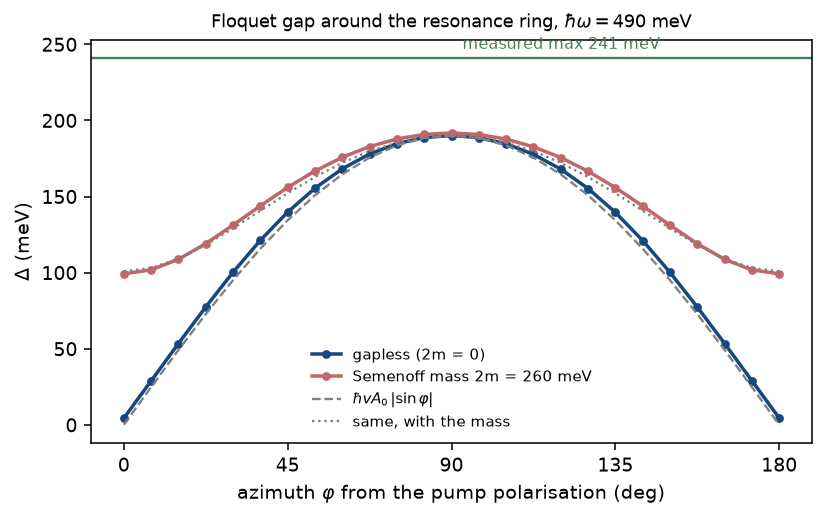


The measurement (their Fig. 4f) follows the dashed curve, with the nodes
intact. The dotted curve is what a genuine 260 meV sublattice mass would
give. The two are separated by far more than the 71 meV resolution.


In [8]:
phis = np.arange(0.0, 181.0, 7.5)
curves = {}
for lab, model, c in (('gapless (2m = 0)', graphene_model(0.0), CAT[0]),
                      (f'Semenoff mass 2m = {GAP_SUB*1e3:.0f} meV', gapped, CAT[1])):
    g = np.array([floquet_gap(model, p, A0_B, W_B)[0] for p in phis])
    curves[lab] = g
    print(f'{lab:32s} Delta(90) = {np.nanmax(g):6.1f} meV, '
          f'Delta(0) = {g[0]:6.1f} meV')

fig, ax = plt.subplots(figsize=(6.0, 3.8), dpi=140)
for (lab, g), c in zip(curves.items(), CAT):
    ax.plot(phis, g, 'o-', ms=3.5, color=c, lw=1.8, label=lab)
dmax = np.nanmax(curves['gapless (2m = 0)'])
ax.plot(phis, dmax * np.abs(np.sin(np.radians(phis))), color='0.5', lw=1.2, ls='--',
        label=r'$\hbar v A_0\,|\sin\varphi|$')
m_over_E = 0.5 * GAP_SUB / (0.5 * W_B)
ax.plot(phis, dmax * np.sqrt(1 - (1 - m_over_E ** 2) * np.cos(np.radians(phis)) ** 2),
        color='0.5', lw=1.2, ls=':', label='same, with the mass')
ax.axhline(241, color=CAT[2], lw=1.2)
ax.text(93, 247, 'measured max 241 meV', color=CAT[2], fontsize=8)
ax.set_xlabel(r'azimuth $\varphi$ from the pump polarisation (deg)')
ax.set_ylabel(r'$\Delta$ (meV)')
ax.set_xticks([0, 45, 90, 135, 180])
ax.set_title(r'Floquet gap around the resonance ring, $\hbar\omega = 490$ meV',
             fontsize=9)
ax.legend(frameon=False, fontsize=7.5)
plt.tight_layout(); plt.show()
print('\nThe measurement (their Fig. 4f) follows the dashed curve, with the nodes')
print('intact. The dotted curve is what a genuine 260 meV sublattice mass would')
print('give. The two are separated by far more than the 71 meV resolution.')

## 5. $\Delta$ is linear in the velocity and in the field — checked, not assumed

Two scalings are worth confirming directly, because they are what lets the
PBE-velocity deficit be quoted as a *correction* rather than an excuse: the gap
must be strictly linear in $A_0$ (unlike the Bi$_2$Se$_3$ Dirac-point gap, which
is quadratic), and strictly linear in the band velocity.

Delta (meV) vs A0 scaling [ 47.8  95.5 190.1 282.5 370.9]


Delta ~ A0^0.9870   (1 in linear response: the crossing gap is FIRST
                          order in A0, unlike a Dirac-point mass, which is
                          second -- see notebook 25)
Delta ~ v^1.0454     (1 in linear response)
The few-percent excess in both is real, not numerical: beta = 0.42 here, so the drive is not a small perturbation and the
exact Sambe gap is not exactly the first-order estimate.

so the PBE velocity deficit propagates as a single factor 1.166:


   192 meV (PBE v = 5.64 eV Ang)  ->  224 meV at the experimental v = 6.58 eV Ang   vs measured 241 +- 18


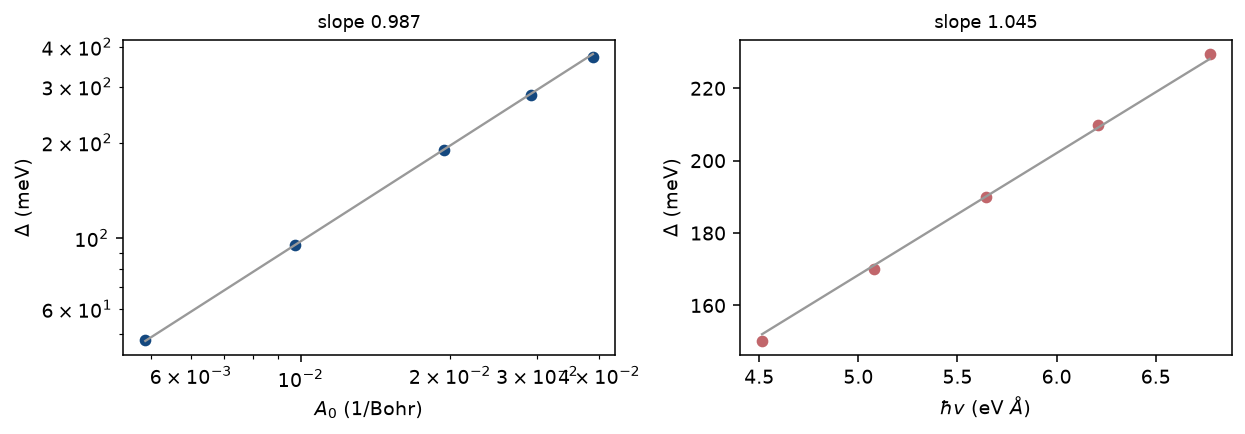

In [9]:
scale = np.array([0.25, 0.5, 1.0, 1.5, 2.0])
g_amp = np.array([floquet_gap(graphene_model(0.0), 90.0, s * A0_B, W_B)[0]
                  for s in scale])
p_amp = np.polyfit(np.log(scale), np.log(g_amp), 1)[0]
print('Delta (meV) vs A0 scaling', np.round(g_amp, 1))

def scaled_velocity_model(f):
    # Scale every A-B hopping, INCLUDING the one inside the home cell. Graphene's
    # B site sits at (a1+a2)/3, so one of the three nearest-neighbour bonds has
    # R = 0; leaving it out scales two bonds of three, breaks C3, and the
    # velocity then does not scale as f at all (the exponent comes out 1.5).
    H = res.hr.H_R.detach().cpu().numpy().copy()
    R0 = np.where((res.hr.R_vectors == 0).all(axis=1))[0][0]
    onsite = H[R0].diagonal().copy()
    H *= f
    H[R0][np.diag_indices(res.hr.nw)] = onsite
    return HamiltonianR(H_R=torch.tensor(H), R_vectors=res.hr.R_vectors,
                        degen=res.hr.degen, nw=res.hr.nw, centres=res.hr.centres,
                        real_lattice=res.hr.real_lattice, mp_grid=res.hr.mp_grid)

facs = np.array([0.8, 0.9, 1.0, 1.1, 1.2])
g_v, v_v = [], []
for f in facs:
    m = scaled_velocity_model(f)
    ee = band_eigensystem(m, kpath_from_K(kk[:4]))[0] * HARTREE_TO_EV - E_F
    v_v.append(float(np.polyfit(kk[:4], 0.5 * (ee[:, 1] - ee[:, 0]), 1)[0]))
    g_v.append(floquet_gap(m, 90.0, A0_B, W_B)[0])
v_v, g_v = np.array(v_v), np.array(g_v)
ok = np.isfinite(v_v) & np.isfinite(g_v) & (g_v > 0)
p_v = np.polyfit(np.log(v_v[ok]), np.log(g_v[ok]), 1)[0]

print(f'Delta ~ A0^{p_amp:.4f}   (1 in linear response: the crossing gap is FIRST')
print(f'                          order in A0, unlike a Dirac-point mass, which is')
print(f'                          second -- see notebook 25)')
print(f'Delta ~ v^{p_v:.4f}     (1 in linear response)')
print(f'The few-percent excess in both is real, not numerical: beta = '
      f'{v_au*A0_B/w_B:.2f} here, so the drive is not a small perturbation and the')
print('exact Sambe gap is not exactly the first-order estimate.')
print(f'\nso the PBE velocity deficit propagates as a single factor '
      f'{HBAR_V_EXP/HV:.3f}:')
g_pbe = floquet_gap(gapped, 90.0, A0_B, W_B)[0]
print(f'   {g_pbe:.0f} meV (PBE v = {HV:.2f} eV Ang)  ->  '
      f'{g_pbe*HBAR_V_EXP/HV:.0f} meV at the experimental v = {HBAR_V_EXP:.2f} eV Ang'
      f'   vs measured 241 +- 18')

fig, axs = plt.subplots(1, 2, figsize=(9, 3.2), dpi=140)
axs[0].loglog(scale * A0_B, g_amp, 'o', color=CAT[0], ms=5)
axs[0].loglog(scale * A0_B, g_amp[2] * scale, '-', color='0.6', lw=1.2)
axs[0].set_xlabel(r'$A_0$ (1/Bohr)'); axs[0].set_ylabel(r'$\Delta$ (meV)')
axs[0].set_title(f'slope {p_amp:.3f}', fontsize=9)
axs[1].plot(v_v[ok], g_v[ok], 'o', color=CAT[1], ms=5)
axs[1].plot(v_v[ok], v_v[ok] / v_v[2] * g_v[2], '-', color='0.6', lw=1.2)
axs[1].set_xlabel(r'$\hbar v$ (eV $\AA$)'); axs[1].set_ylabel(r'$\Delta$ (meV)')
axs[1].set_title(f'slope {p_v:.3f}', fontsize=9)
plt.tight_layout(); plt.show()

## What this establishes

* **The switch between the two experiments is reproduced.** One model, one
  substrate gap: at 246 meV there is no resonance ring and no gap, only replicas
  — Choi *et al.*'s result and their stated reason; at 490 and 600 meV the ring
  exists and gaps open.
* **The gap size.** PBE's own velocity gives 192 meV; rescaled by the single
  factor $v_{\rm exp}/v_{\rm PBE} = 1.17$ that becomes 224 meV, inside the
  measured $241\pm18$. The rescaling is legitimate because $\Delta \propto
  A_0^{0.99}v^{1.05}$ is verified numerically rather than assumed. Note the contrast with notebook 25: the Bi$_2$Se$_3$
  Dirac-point gap under *circular* light is second order ($\propto v^2A_0^2$),
  the crossing gap here is first order, and both come out of the same code with
  no switch thrown.
* **A disagreement worth having.** The measured anisotropy has clean nodes along
  the pump polarisation. A genuine 260 meV sublattice mass would fill them to
  ~130 meV. Something has to give: either the epitaxial gap is not a Semenoff
  mass in the driven manifold, or it is smaller at the probed momenta than the
  0.26–0.27 eV quoted. The calculation cannot decide which, but it does say the
  two published statements are not simultaneously consistent.

## What it does not

Everything notebook 25 disclaims — infinite-time, non-interacting, no pulse
envelope, no dephasing, no populations. Two things specific to graphene:

* **Volkov states.** Choi *et al.*'s central finding is that the replica
  intensities in their data come from *interference* between Floquet-Bloch and
  Volkov states — light-dressed free-electron photoemission final states, a
  final-state effect entirely outside this calculation. Wang *et al.* suppress
  them with near-normal incidence. So the replica intensities computed above are
  not comparable to Choi *et al.*'s; the positions and the absence of a gap are.
* **Dissipation.** Wang *et al.* argue the decade-long difficulty was scattering
  destroying coherence before the drive could dress the bands, and list sample
  quality and a sub-100 fs probe among the advances that made it work. None of
  that is in a Floquet quasi-energy spectrum, which assumes the dressing is
  complete.